### Imports

In [1]:
import random
import datetime

import numpy as np

import qutip as qt
import qutip_qtrl.pulseoptim as cpo
import qutip_qoc as qoc

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mpl_colors

from IPython.display import HTML
from matplotlib import animation

%load_ext autoreload
%autoreload 2

from utils import *

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

### System parameters

In [39]:
N_default = 80
gkp_delta = 0.3
gkp_cutoff = 20
gkp_alpha = np.sqrt(np.pi / 2)
gkp_beta = np.sqrt(np.pi/ 2) * 1j

# Kerr nonlinearity
K = 0.1

In [40]:
def generate_system_operators(squeezing=0):
    N = max(10 * np.sinh(s), N_default)
    
    # Generate states
    gkp_0, gkp_1 = generate_gkp_state(N, gkp_alpha, gkp_beta, gkp_delta, gkp_cutoff)
    initial_state = qt.squeeze(N, s) * qt.basis(N, 0)
    target_state = gkp_0

    # Creation operator
    a = qt.create(N)

    # Drift Hamiltonian
    drift_hamiltonian = K * (a.dag() * a)**2
    
    # Control Hamiltonian
    H_tpd = a.dag()**2 + a**2
    H_tpd_conj = 1j * (a.dag()**2 - a**2)
    H_disp_x = a + a.dag()
    H_disp_p = 1j * (a.dag() - a)
    
    control_hamiltonian = [
        H_disp_x,
        H_disp_p,
        H_tpd,
        H_tpd_conj,
    ]
    # control_labels = [r"$Re[G(t)]$", r"$Im[G(t)]$"]
    control_labels = [r"$Re[e(t)]$", r"$Im[e(t)]$", r"$Re[G(t)]$", r"$Im[G(t)]$"]

    return initial_state, target_state, drift_hamiltonian, control_hamiltonian, control_labels

### Run optimal control

In [48]:
# Optimal control parameters
config = {
    "alg": "GRAPE",
    "num_tslots": 1000, # Number of time slots
    "evo_time": 10, # Time allowed for the evolution
    "fid_err_targ": 1e-4, # Fidelity error target
    "max_iter": 1000, # Maximum iterations for the optisation algorithm
    "max_wall_time": 300, # Maximum (elapsed) time allowed in seconds
    "min_grad": 1e-5,
    "init_pulse_type": "SINE",
    "out_file_ext": None,
    "gen_stats": True,
}

In [49]:
# Define initial squeezing
squeezing = [0.0, 0.5, 1.0]

results = []
for i, s in enumerate(squeezing):
    print(f"Running optimal control for squeezed state r={s}")

    # Generate states and Hamiltonians
    initial_state, target_state, drift_hamiltonian, control_hamiltonian, control_labels = generate_system_operators(squeezing=0)

    # Run optimal control
    result = cpo.optimize_pulse_unitary(
        drift_hamiltonian,
        control_hamiltonian,
        initial_state,
        target_state,
        **config,
    )
    results.append(result)
    
    print("********* Summary *****************")
    print("Final fidelity error {}".format(result.fid_err))
    print("Final gradient normal {}".format(result.grad_norm_final))
    print("Terminated due to {}".format(result.termination_reason))
    print("Number of iterations {}".format(result.num_iter))
    print("Completed in {} HH:MM:SS.US".format(datetime.timedelta(seconds=result.wall_time)))
    print()

Running optimal control for squeezed state r=0.0
********* Summary *****************
Final fidelity error 0.009617749164738898
Final gradient normal 0.03553664541003738
Terminated due to Max wall time exceeded
Number of iterations 60
Completed in 0:05:00.707141 HH:MM:SS.US

Running optimal control for squeezed state r=0.5
********* Summary *****************
Final fidelity error 0.01855321023684553
Final gradient normal 0.027383343410174583
Terminated due to Max wall time exceeded
Number of iterations 63
Completed in 0:05:02.999586 HH:MM:SS.US

Running optimal control for squeezed state r=1.0
********* Summary *****************
Final fidelity error 0.015819370092685303
Final gradient normal 0.05901460093118269
Terminated due to Max wall time exceeded
Number of iterations 71
Completed in 0:05:01.105869 HH:MM:SS.US



### Visualize pulses

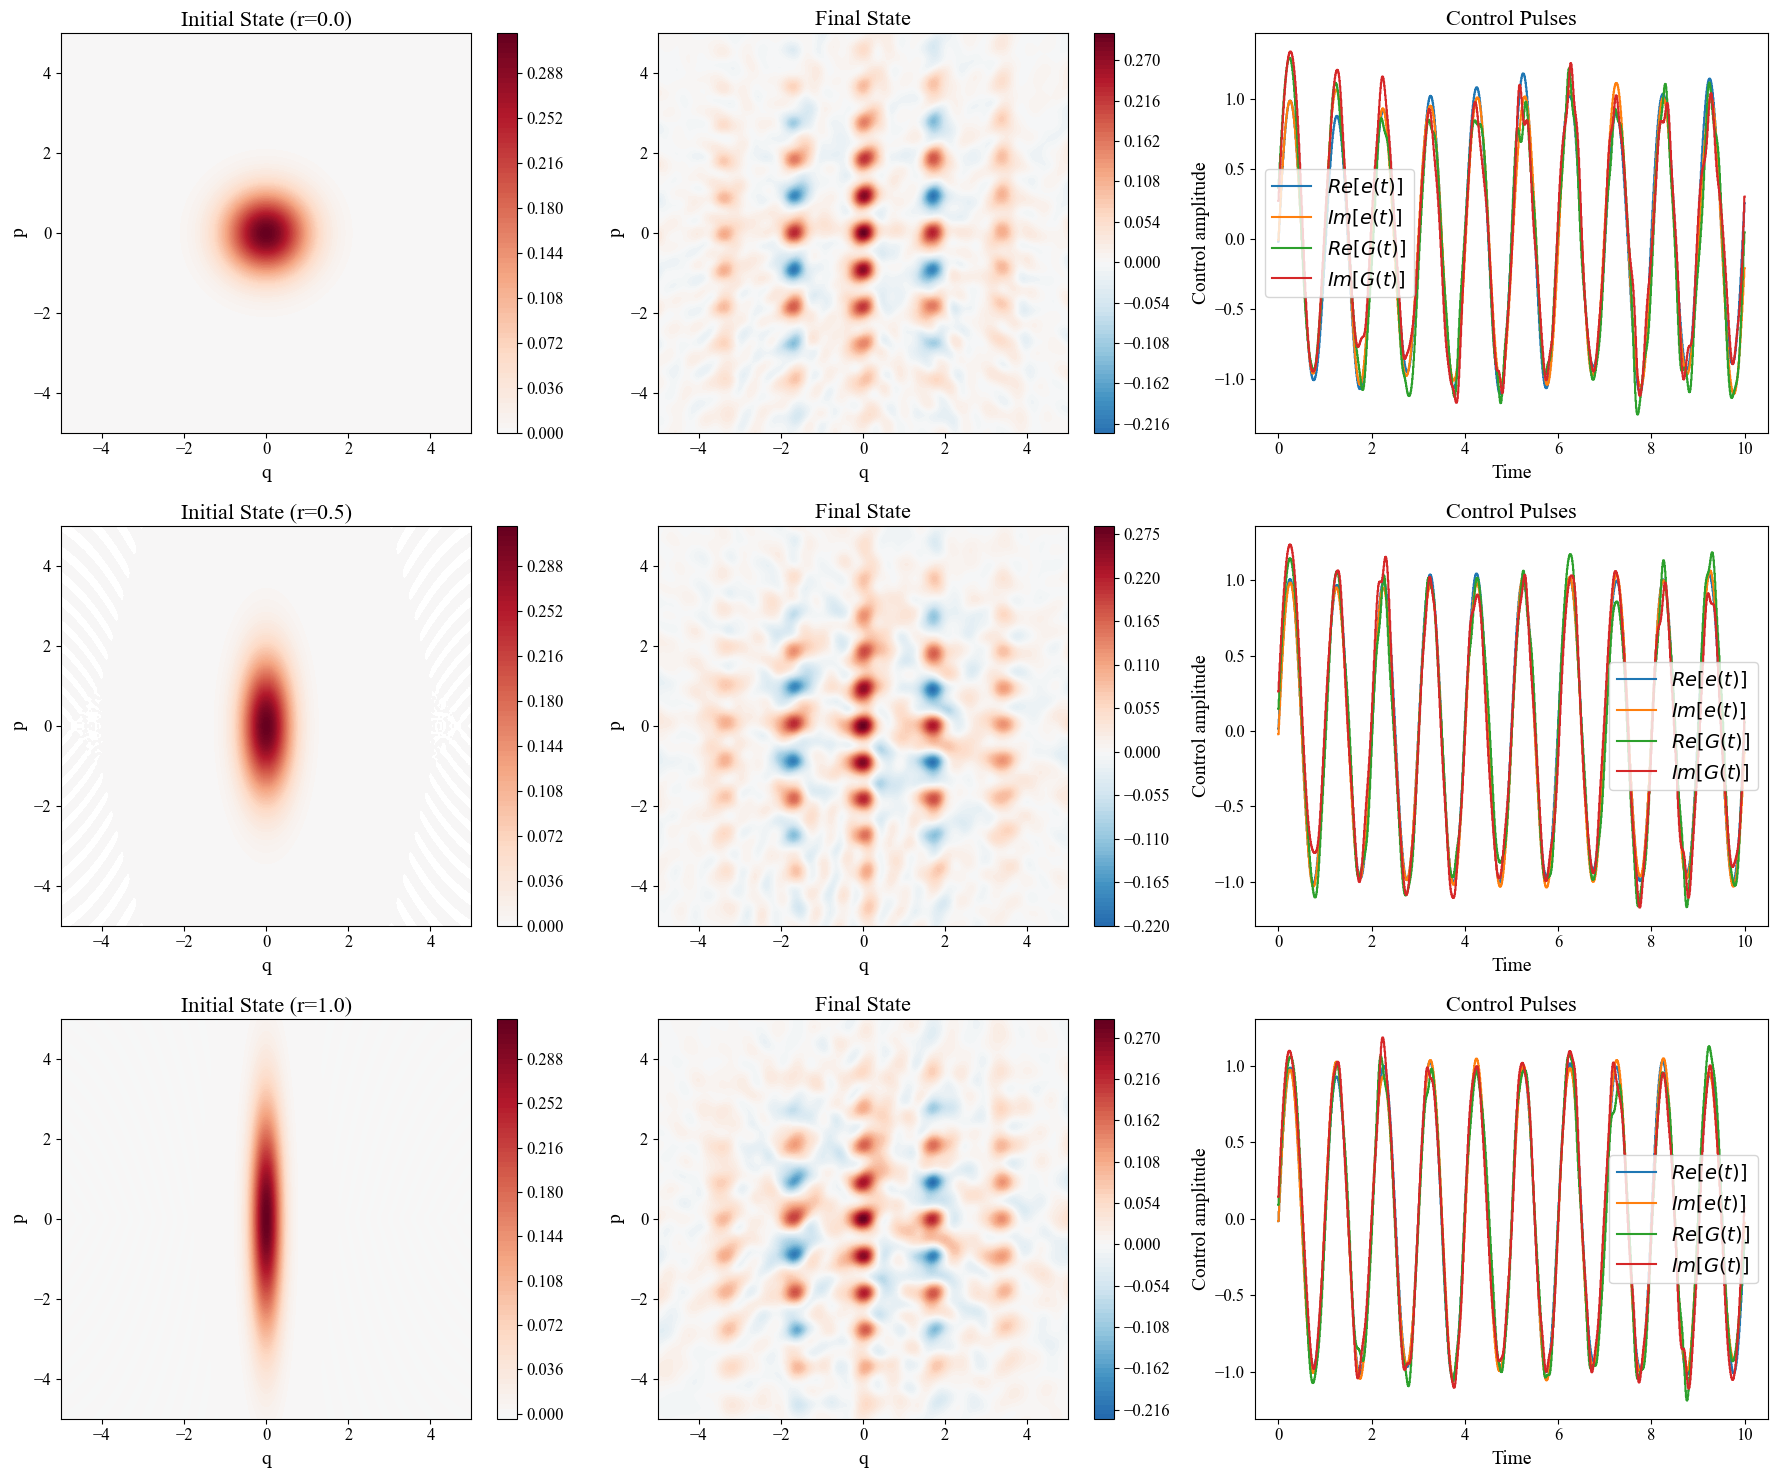

In [53]:
# Plot initial state, final state, and pulse
output_file_name = f"../figs/squeezed_to_gkp/microwave_drive_and_two_photon_drive_controls_{squeezing}.pdf"
fig, axs = plt.subplots(len(squeezing), 3, figsize=(18,len(squeezing) * 5))

# Ensure axs is always 2D
axs = np.atleast_2d(axs)

for i, s in enumerate(squeezing):
    # Generate states and Hamiltonians
    initial_state, target_state, drift_hamiltonian, control_hamiltonian, control_labels = generate_system_operators(squeezing=0)

    # Simulate time evolution
    h_tot, tlist = generate_hamiltonian(drift_hamiltonian, control_hamiltonian, results[i].final_amps, 10)
    res = qt.mesolve(h_tot, initial_state, tlist, [])
    final_state = res.states[-1]

    # Plot wigner functions and pulse
    plot_wigner_function(initial_state, x_bound=5, y_bound=5, title=f"Initial State (r={s})", ax=axs[i,0])
    plot_wigner_function(final_state, x_bound=5, y_bound=5, title=f"Final State", ax=axs[i,1])
    plot_pulse(results[i], title=f"Control Pulses", labels=control_labels, ax=axs[i,2])
    
if output_file_name:
    plt.savefig(output_file_name, bbox_inches="tight")

plt.tight_layout()
plt.show()

In [54]:
# Save data
output_file_name = f"microwave_and_two_photon_drive_pulses"
if output_file_name:
    for i, s in enumerate(squeezing):
        np.save(f'../data/squeezed_to_gkp/{output_file_name}_{s}.npy', results[i].final_amps)

### Wigner function animations

In [57]:
# Generate Wigner states
xvec = np.linspace(-5,5,100)
yvec = xvec

state_evolution_results = []
wigner_states = []

for i, s in enumerate(squeezing[:1]):
    initial_state, target_state, drift_hamiltonian, control_hamiltonian, control_labels = generate_system_operators(squeezing=0)
    h_tot, tlist = generate_hamiltonian(drift_hamiltonian, control_hamiltonian, results[i].final_amps, 10)

    result = qt.mesolve(h_tot, initial_state, tlist, [])
    state_evolution_results.append(result)

    wigners = []
    for state in result.states:
        wigners.append(qt.wigner(state, xvec, yvec))
    print(f"Generated squeezed state {s} Wigner states")
    wigner_states.append(wigners)

Generated squeezed state 0.0 Wigner states


In [ ]:
# Create Wigner Animation
from IPython.display import Video

for i, s in enumerate(squeezing):
    save_path = f"../vid/squeezed_to_gkp/wigner_animation_microwave_two_photon_drive_{s}.mp4"
    create_wigner_animation(wigner_states[i], xvec, save_path=save_path, interval=10)
    Video(save_path)